# Extract context-specific regulator embeddings from ChromBERT

This notebook shows how to extract regulator embeddings using the ChromBERT-tools Python API.

`embed_regulator` API: Generate regulator embeddings for input regulators across user-specified regions.

`umap_plot` API: Visualize regulator embeddings with UMAP using user-defined annotations.

For more details, please refer to the [`embed_regulator`](https://chrombert-tools.readthedocs.io/en/latest/commands/embed_regulator.html) command documentation.


In [1]:
from chrombert_tools import embed_regulator, umap_plot
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1" # GPU device

### Example 1

In [2]:
# Returns:
# - regulator_means: A Python dictionary mapping each matched regulator to its 768-dimensional mean embedding.
# - regulator_emb_dict: A Python dictionary mapping each matched regulator to its Region-aware regulator embeddings
# - overlap_region_bed: Input regions that overlap ChromBERT reference bins.
results = embed_regulator(
    region='../data/CTCF_ENCFF664UGR_sample100.bed', # your region
    regulator="EZH2;BRD4;CTCF;FOXA3;myod1;myF5", # your regulators
    odir="./output_emb_regulator_1kb", # output directory
    genome="hg38",        # Options: "hg38", "mm10"
    resolution="1kb",     # Options: "1kb", "2kb", "4kb", "200bp"
)
mean_regulator_embs_dict = results.regulator_means #  Dict[regulator_name, mean_embedding], shape (768,)
regulator_emb_dict = results.regulator_emb_dict # Dict[regulator_name, per_region_embeddings], shape (N_regions, 768)
regions = results.overlap_region_bed # DataFrame with columns [chrom, start, end, build_region_index,start_input,end_input]





Region summary - total: 100, overlapping with ChromBERT: 100 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 0
Note: All regulator names were converted to lowercase for matching.
Regulator count summary - requested: 6, matched in ChromBERT: 5, not found: 1, not found regulator: ['foxa3']
ChromBERT regulators: /mnt/Storage/home/chenqianqian/.cache/chrombert/data/config/hg38_6k_regulators_list.txt
Load pretrained ckpt /mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_1kb_pretrain.ckpt successfully!
Your supervised_file does not contain the 'label' column. Please verify whether ground truth column ('label') is required. If it is not needed, you may disregard this message.
Your supervised_file does not contain the 'label' column. Please verify whether ground truth column ('label') is required. If it is not needed, you may disregard this message.


Computing regulator embeddings: 100%|██████████| 25/25 [00:02<00:00,  8.47it/s]



Finished!
Focus region summary - total: 100, overlapping with ChromBERT: 100, non-overlapping: 0
Overlapping regions BED file: ./output_emb_regulator_1kb/overlap_region.bed
Non-overlapping regions BED file: ./output_emb_regulator_1kb/no_overlap_region.bed
Mean regulator embeddings saved to: ./output_emb_regulator_1kb/mean_regulator_emb.pkl
Region-aware regulator embeddings saved to: ./output_emb_regulator_1kb/region_aware_regulator_emb.hdf5
Embedding type: general


In [3]:
# Python dictionary mapping each matched regulator to its 768-dimensional mean embedding.
for key, value in mean_regulator_embs_dict.items():
    print(key, value.shape)


myf5 (768,)
ezh2 (768,)
ctcf (768,)
myod1 (768,)
brd4 (768,)


In [4]:
# Python dictionary mapping each matched regulator to its Region-aware regulator embeddings
for key, value in regulator_emb_dict.items():
    print(key, value.shape)

myf5 (100, 768)
ezh2 (100, 768)
ctcf (100, 768)
myod1 (100, 768)
brd4 (100, 768)


In [5]:
# Input regions

import pandas as pd
input_bed = pd.read_csv("../data/CTCF_ENCFF664UGR_sample100.bed",sep='\t',header=None)
input_bed.head()

,0,1,2,3,4,5,6,7,8,9
0,chr16,18801589,18802050,.,1000,.,763.04942,-1.0,5.16371,223
1,chr16,57648947,57649478,.,1000,.,758.51709,-1.0,5.16371,268
2,chr20,36605339,36605842,.,1000,.,756.09888,-1.0,5.16371,234
3,chr2,46986976,46987465,.,1000,.,747.99355,-1.0,5.16371,233
4,chr16,28945489,28946040,.,1000,.,747.87076,-1.0,5.16371,263


In [6]:
# Input regions that overlap ChromBERT reference bins.

regions

,chrom,start,end,build_region_index,start_input,end_input
0,1,37990000,37991000,32658,37989946,37990368
1,11,2400000,2401000,289179,2400199,2400617
2,12,6779000,6780000,391108,6778809,6779319
3,12,52981000,52982000,424926,52980788,52981316
4,12,53676000,53677000,425578,53676021,53676448
...,...,...,...,...,...,...
95,6,53172000,53173000,1660979,53171843,53172315
96,6,131628000,131629000,1713078,131628105,131628616
97,6,158704000,158705000,1735665,158704189,158704642
98,9,128117000,128118000,2049996,128117589,128118035


### Example 2

In [7]:
results_max = embed_regulator(
    region = "../data/max_k562_downsample_region.csv", # your region
    regulator = "max", # your regulators
    odir = "max_k562", # output directory
    oname = "max_emb", # output name
    genome = "hg38", # genome
)


Region summary - total: 400, overlapping with ChromBERT: 400 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 0
Note: All regulator names were converted to lowercase for matching.
Regulator count summary - requested: 1, matched in ChromBERT: 1, not found: 0, not found regulator: []
ChromBERT regulators: /mnt/Storage/home/chenqianqian/.cache/chrombert/data/config/hg38_6k_regulators_list.txt
Load pretrained ckpt /mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_1kb_pretrain.ckpt successfully!


Computing regulator embeddings: 100%|██████████| 100/100 [00:07<00:00, 13.70it/s]


Finished!
Focus region summary - total: 401, overlapping with ChromBERT: 400, non-overlapping: 0
Overlapping regions BED file: max_k562/overlap_region.bed
Non-overlapping regions BED file: max_k562/no_overlap_region.bed
Mean regulator embeddings saved to: max_k562/mean_max_emb.pkl
Region-aware regulator embeddings saved to: max_k562/region_aware_max_emb.hdf5
Embedding type: general


In [8]:
# Returns:
# - regulator_means: A Python dictionary mapping each matched regulator to its 768-dimensional mean embedding.
# - regulator_emb_dict: A Python dictionary mapping each matched regulator to its Region-aware regulator embeddings
# - overlap_region_bed: Input regions that overlap ChromBERT reference bins.

mean_regulator_embs_dict_max = results_max.regulator_means
regulator_emb_dict_max = results_max.regulator_emb_dict
regions_max = results_max.overlap_region_bed

In [9]:
regulator_emb_dict_max.keys()


dict_keys(['max'])

In [10]:
regulator_emb_dict_max['max'].shape,regulator_emb_dict_max['max']

((400, 768),
 array([[-0.05834961,  0.96484375,  0.70703125, ...,  0.10839844,
          0.5390625 ,  1.828125  ],
        [-0.0456543 ,  0.5703125 ,  0.20214844, ..., -0.70703125,
         -0.61328125,  0.8828125 ],
        [ 0.7421875 ,  1.4765625 ,  0.09716797, ...,  0.31445312,
          1.40625   ,  2.703125  ],
        ...,
        [ 2.75      ,  0.29882812,  1.953125  , ..., -0.80078125,
         -0.87890625, -1.3515625 ],
        [ 3.515625  ,  0.48632812,  1.71875   , ..., -1.03125   ,
         -0.8046875 , -1.65625   ],
        [ 4.1875    ,  1.734375  ,  2.46875   , ...,  0.36328125,
         -0.34765625, -1.1015625 ]], dtype=float32))

In [15]:
# Map each region to its user-defined annotation class

# Convert chromosome identifiers to standard chromosome names
def chrom_int_to_series(chrom):
    chrom = str(chrom)
    if not chrom.startswith("chr"):
        chrom = "chr" + chrom
    if chrom == "chr23":
        chrom = "chrX"
    if chrom == "chr24":
        chrom = "chrY"

    return chrom



input_df = pd.read_csv("../data/max_k562_downsample_region.csv") # Your input regions
input_df.head()
input_df.columns = ["chrom","start_input","end_input","build_region_index","anno"]

regions_max["chrom"] = regions_max["chrom"].apply(chrom_int_to_series) # Input regions that overlap ChromBERT reference bins. Convert chromosome identifiers to standard chromosome names, 
regions_max = regions_max.merge(input_df[["chrom","start_input","end_input","anno"]],on=["chrom","start_input","end_input"])
regions_max

,chrom,start,end,build_region_index,start_input,end_input,label,anno
0,chr1,976000,977000,270,976000,977000,1,1
1,chr1,1925000,1926000,1146,1925000,1926000,1,1
2,chr1,6702000,6703000,5117,6702000,6703000,1,1
3,chr1,8251000,8252000,6517,8251000,8252000,0,0
4,chr1,10724000,10725000,8797,10724000,10725000,1,1
...,...,...,...,...,...,...,...,...
395,chrX,102658000,102659000,2108176,102658000,102659000,0,0
396,chrX,119639000,119640000,2117400,119639000,119640000,0,0
397,chrX,133289000,133290000,2124292,133289000,133290000,0,0
398,chrX,145290000,145291000,2129954,145290000,145291000,0,0


/mnt/Storage/home/chenqianqian/miniconda3/envs/chrombert/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


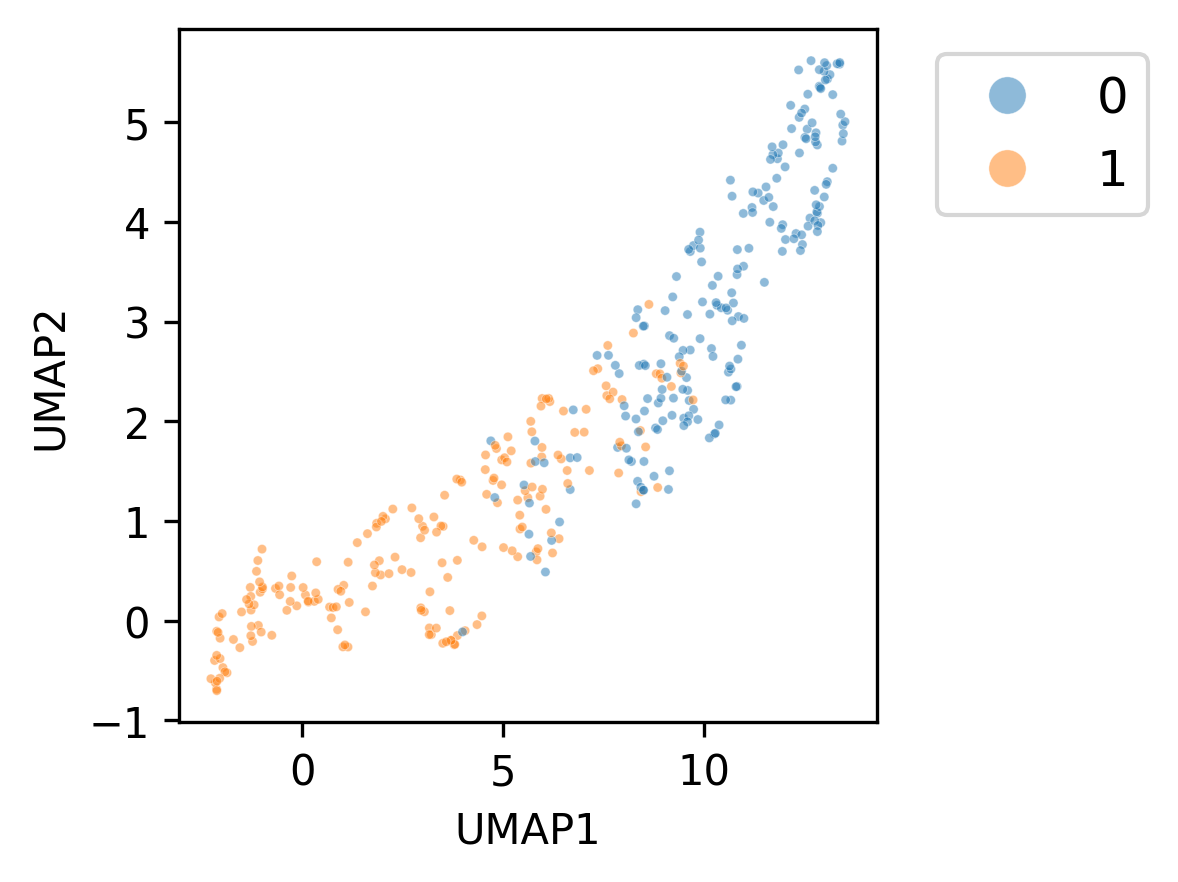

In [16]:
umap_plot(
    regulator_emb_dict_max['max'],
    regions_max["anno"],
    odir = "max_k562",
)

### 200bp

In [ ]:
# Returns:
# - regulator_means: A Python dictionary mapping each matched regulator to its 768-dimensional mean embedding.
# - regulator_emb_dict: A Python dictionary mapping each matched regulator to its Region-aware regulator embeddings
# - overlap_region_bed: Input regions that overlap ChromBERT reference bins.

results_max_200bp = embed_regulator(
    region = "../data/max_k562_downsample_region.csv",
    regulator = "max",
    odir = "max_k562_200bp",
    oname = "max_emb",
    genome = "hg38",
    resolution = "200bp",
)
mean_regulator_embs_dict_max_200bp = results_max_200bp.regulator_means
regulator_emb_dict_max_200bp = results_max_200bp.regulator_emb_dict
regions_max_200bp = results_max_200bp.overlap_region_bed

Region summary - total: 400, overlapping with ChromBERT: 1373 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 400
Note: All regulator names were converted to lowercase for matching.
Regulator count summary - requested: 1, matched in ChromBERT: 1, not found: 0, not found regulator: []
ChromBERT regulators: /mnt/Storage/home/chenqianqian/.cache/chrombert/data/config/hg38_6k_regulators_list.txt
Load pretrained ckpt /mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_200bp_pretrain.ckpt successfully!


Computing regulator embeddings: 100%|██████████| 344/344 [00:23<00:00, 14.64it/s]


Finished!
Focus region summary - total: 401, overlapping with ChromBERT: 1373, non-overlapping: 400
Overlapping regions BED file: max_k562_200bp/overlap_region.bed
Non-overlapping regions BED file: max_k562_200bp/no_overlap_region.bed
Mean regulator embeddings saved to: max_k562_200bp/mean_max_emb.pkl
Region-aware regulator embeddings saved to: max_k562_200bp/region_aware_max_emb.hdf5
Embedding type: general


/mnt/Storage/home/chenqianqian/miniconda3/envs/chrombert/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


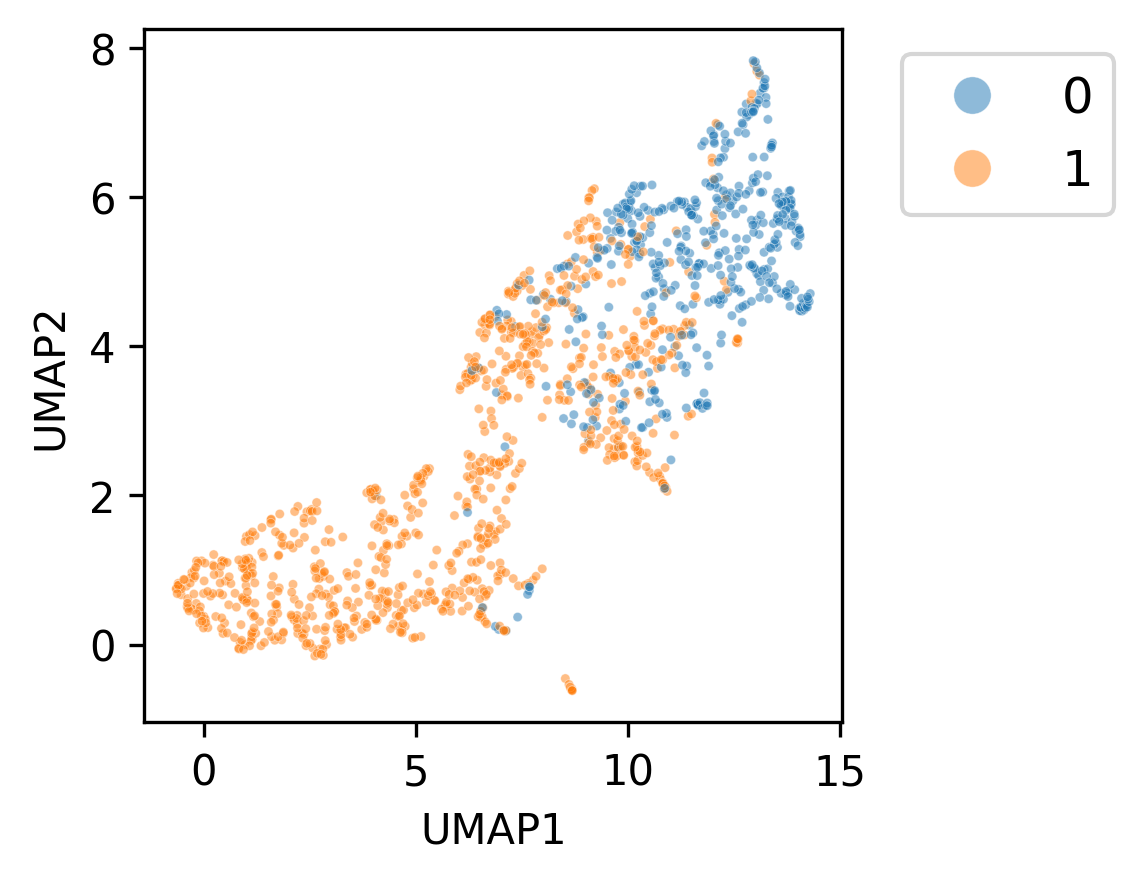

In [15]:
umap_plot(
    regulator_emb_dict_max_200bp['max'],
    regions_max_200bp["label"],
    odir = "max_k562_200bp",
)

### Generate cell-type-specific embeddings using a fine-tuned checkpoint

We use a fine-tuned checkpoint as input.

The `embed_regulator` API uses this checkpoint to generate context-specific embeddings.

In [ ]:
### fine-tuned a cell-type-specific model
# from chrombert_tools import region_activity_regression
# results_myoblast_specific = region_activity_regression(
#     odir = "./output_cell_specific_emb_train", # output directory
#     acc_signal1 = "../data/myoblast_ENCFF149ERN_signal.bigwig", # your focus cell-type accessibility data
#     acc_peak1 = "../data/myoblast_ENCFF647RNC_peak.bed", # your focus cell-type peak data
#     genome = "hg38", # genome
#     resolution = "1kb", # resolution
# )


In [ ]:
import glob
from chrombert_tools import embed_regulator
ft_ckpt_dir = "./output_cell_specific_emb_train/train/**/*.ckpt"  # Use checkpoints from embed_region.ipynb if available; otherwise, run the code above first

ft_ckpt = glob.glob(ft_ckpt_dir, recursive=True)[0]
ft_ckpt


'./output_cell_specific_emb_train/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=0-step=63.ckpt'

In [ ]:
results_myoblast_specific_2 = embed_regulator(
    region = "../data/myoblast_ENCFF647RNC_peak_100.bed", # Your input regions
    regulator = "myf5", # Your regulators
    odir = "./output_cell_specific_emb_myf5", # Output directory
    ft_ckpt = ft_ckpt, # Fine-tuned checkpoint
    genome = "hg38", # Genome
    resolution = "1kb", # Resolution
)

Region summary - total: 100, overlapping with ChromBERT: 101 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 0
Note: All regulator names were converted to lowercase for matching.
Regulator count summary - requested: 1, matched in ChromBERT: 1, not found: 0, not found regulator: []
ChromBERT regulators: /mnt/Storage/home/chenqianqian/.cache/chrombert/data/config/hg38_6k_regulators_list.txt
Using provided fine-tuned checkpoint: ./output_cell_specific_emb_train/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=0-step=63.ckpt
Load pretrained ckpt /mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_1kb_pretrain.ckpt successfully!
Loading checkpoint from ./output_cell_specific_emb_train/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=0-step=63.ckpt
Loading from pl module, remove prefix 'model.'
Loading from 

Computing regulator embeddings: 100%|██████████| 26/26 [00:02<00:00, 12.77it/s]


Finished!
Focus region summary - total: 100, overlapping with ChromBERT: 101, non-overlapping: 0
Overlapping regions BED file: ./output_cell_specific_emb_myf5/overlap_region.bed
Non-overlapping regions BED file: ./output_cell_specific_emb_myf5/no_overlap_region.bed
Mean regulator embeddings saved to: ./output_cell_specific_emb_myf5/mean_regulator_emb.pkl
Region-aware regulator embeddings saved to: ./output_cell_specific_emb_myf5/region_aware_regulator_emb.hdf5
Embedding type: cell-specific


In [18]:
results_myoblast_specific_2.regulator_means["myf5"].shape

(768,)

In [19]:
results_myoblast_specific_2.regulator_emb_dict["myf5"].shape

(101, 768)

In [20]:
results_myoblast_specific_2.regulator_emb_dict["myf5"]

array([[ 0.44140625,  1.53125   ,  1.96875   , ..., -0.84375   ,
        -1.7265625 ,  1.890625  ],
       [-0.8984375 ,  1.65625   ,  2.484375  , ..., -1.5625    ,
        -1.421875  ,  2.859375  ],
       [ 0.01367188,  1.34375   ,  0.296875  , ..., -1.4375    ,
        -0.9453125 ,  0.27148438],
       ...,
       [-3.71875   ,  0.58203125, -0.45898438, ..., -0.9453125 ,
        -0.94140625,  2.21875   ],
       [-2.5       ,  1.421875  , -1.6953125 , ..., -0.14453125,
        -0.93359375,  2.28125   ],
       [-1.265625  ,  1.890625  , -2.921875  , ...,  0.08789062,
         0.7890625 ,  2.390625  ]], dtype=float32)

### Generate cell-type-specific embeddings

We use cell-type-specific chromatin accessibility peak and signal files as input.

The `embed_regulator` API uses these data to build a cell-type-specific model and generate cell-type-specific embeddings.

In [ ]:
results_myoblast_specific_3 = embed_regulator(
    region = "../data/myoblast_ENCFF647RNC_peak_100.bed", # Your input regions
    regulator = "myf5", # Your regulators
    odir = "./output_cell_specific_emb_myf5", # Output directory
    cell_type_bw = "../data/myoblast_ENCFF149ERN_signal.bigwig", # your focus cell-type accessibility data
    cell_type_peak = "../data/myoblast_ENCFF647RNC_peak.bed", # your focus cell-type peak data   
    genome = "hg38", # Genome
    resolution = "1kb", # Resolution
)